In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import matplotlib as mpl

from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict
from sklearn.svm import SVC

from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    balanced_accuracy_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    make_scorer
)

**LOAD DATA**

In [2]:
X_train = pd.read_csv("X_train_final.csv")
X_test = pd.read_csv("X_test_final.csv")

y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

In [3]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        probability=True,
        C=0.08,
        kernel="linear",
        class_weight="balanced",
        random_state=42
    ))
])

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [5]:
scoring = {
    "macro_f1": make_scorer(f1_score, average="macro")
}

In [6]:
cv_results = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

In [7]:
macro_f1_scores = cv_results["test_macro_f1"]

print("CV Macro F1: %.3f ± %.3f" %
      (macro_f1_scores.mean(), macro_f1_scores.std()))

CV Macro F1: 0.861 ± 0.057


In [8]:
y_prob_train = cross_val_predict(
    pipeline,
    X_train,
    y_train, # Ensure y_train is a 1D array
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:,1]

In [9]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for t in thresholds:
    preds = (y_prob_train >= t).astype(int)
    f1_scores.append(f1_score(y_train, preds, average="macro"))

best_threshold = thresholds[np.argmax(f1_scores)]

print("Best threshold from CV:", round(best_threshold,3))
print("Best CV Macro F1:", round(max(f1_scores),3))

Best threshold from CV: 0.4
Best CV Macro F1: 0.865


In [10]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 SVC(C=0.08, class_weight='balanced', kernel='linear',
                     probability=True, random_state=42))])

In [11]:
y_prob = pipeline.predict_proba(X_test)[:,1]

In [12]:
y_pred = (y_prob >= best_threshold).astype(int)

In [13]:
macro_f1 = f1_score(y_test, y_pred, average="macro")
balanced_acc = balanced_accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("TEST SET PERFORMANCE")
print("--------------------")
print(f"Macro F1: {macro_f1:.2f}")
print(f"Balanced Accuracy: {balanced_acc:.2f}")
print(f"MCC: {mcc:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")
print(f"PR-AUC: {pr_auc:.2f}")

TEST SET PERFORMANCE
--------------------
Macro F1: 0.85
Balanced Accuracy: 0.87
MCC: 0.71
ROC-AUC: 0.87
PR-AUC: 0.75


**CONFUSION MATRIX**

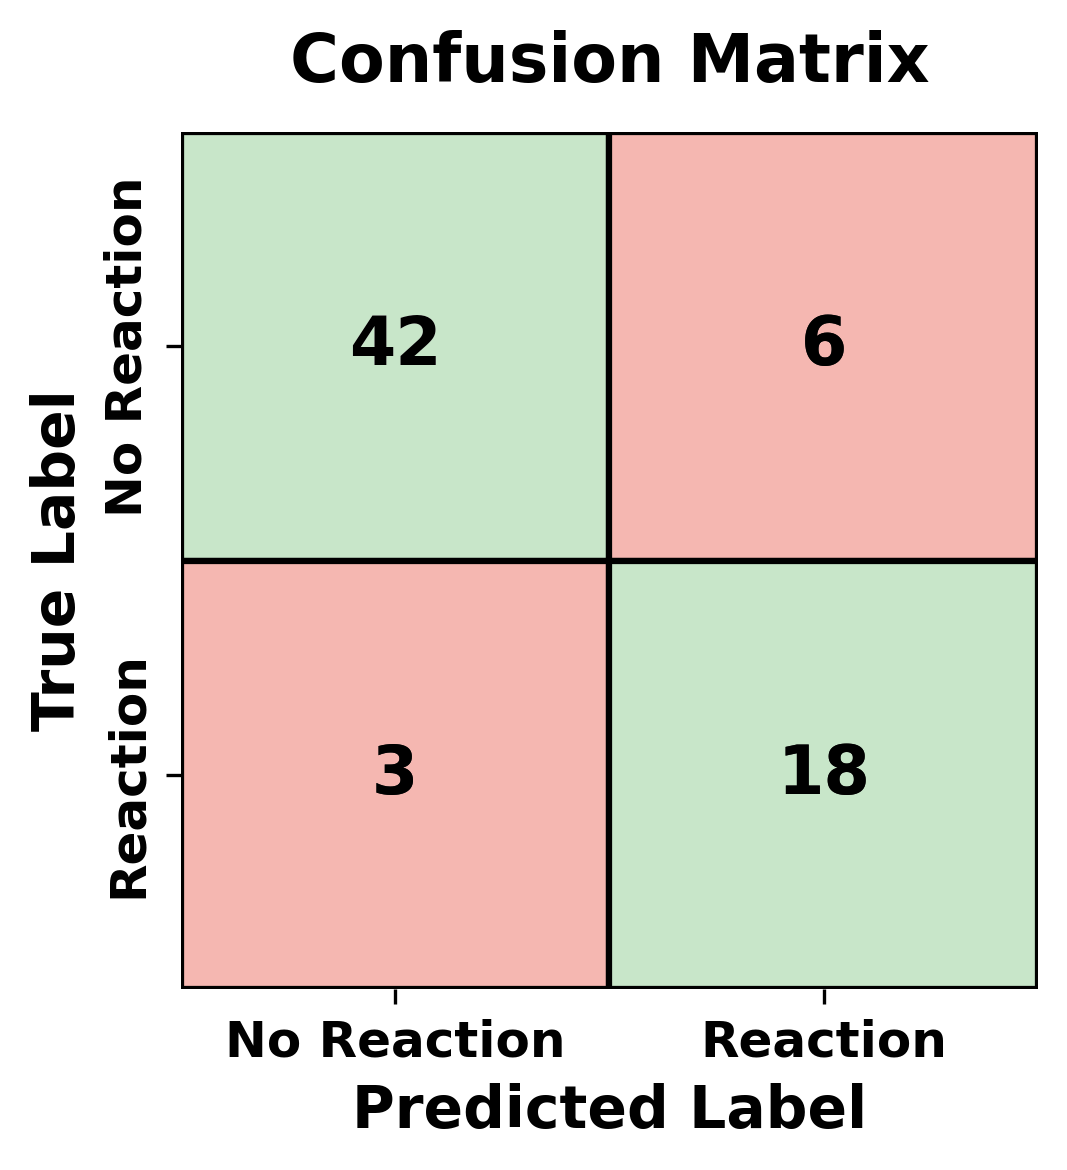

In [15]:
cm = confusion_matrix(y_test, y_pred)

labels = ["No Reaction", "Reaction"]

plt.figure(figsize=(5,4), dpi=300)

ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greys",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=1,
    linecolor="black",
    square=True,
    cbar=False,
    annot_kws={"size":16, "weight":"bold"}
)

colors = np.array([
    ["#c8e6c9", "#f5b7b1"],
    ["#f5b7b1", "#c8e6c9"]
])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.add_patch(plt.Rectangle(
            (j, i), 1, 1,
            fill=True,
            color=colors[i, j],
            ec='black',
            lw=1.5
        ))


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j + 0.5, i + 0.5,
            f"{cm[i, j]}",
            ha='center', va='center',
            fontsize=16, fontweight="bold", color="black"
        )

ax.set_xlabel("Predicted Label", fontsize=14, fontweight="bold")
ax.set_ylabel("True Label", fontsize=14, fontweight="bold")
ax.set_title("Confusion Matrix", fontsize=16, fontweight="bold", pad=12)

ax.tick_params(axis='both', labelsize=12)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

plt.tight_layout()
plt.show()

**SHAP Summary Plot (SHAP beeswarm plot)**

In [17]:
X_train_scaled = pipeline.named_steps["scaler"].transform(X_train)
X_test_scaled = pipeline.named_steps["scaler"].transform(X_test)

In [18]:
svm_model = pipeline.named_steps["model"]

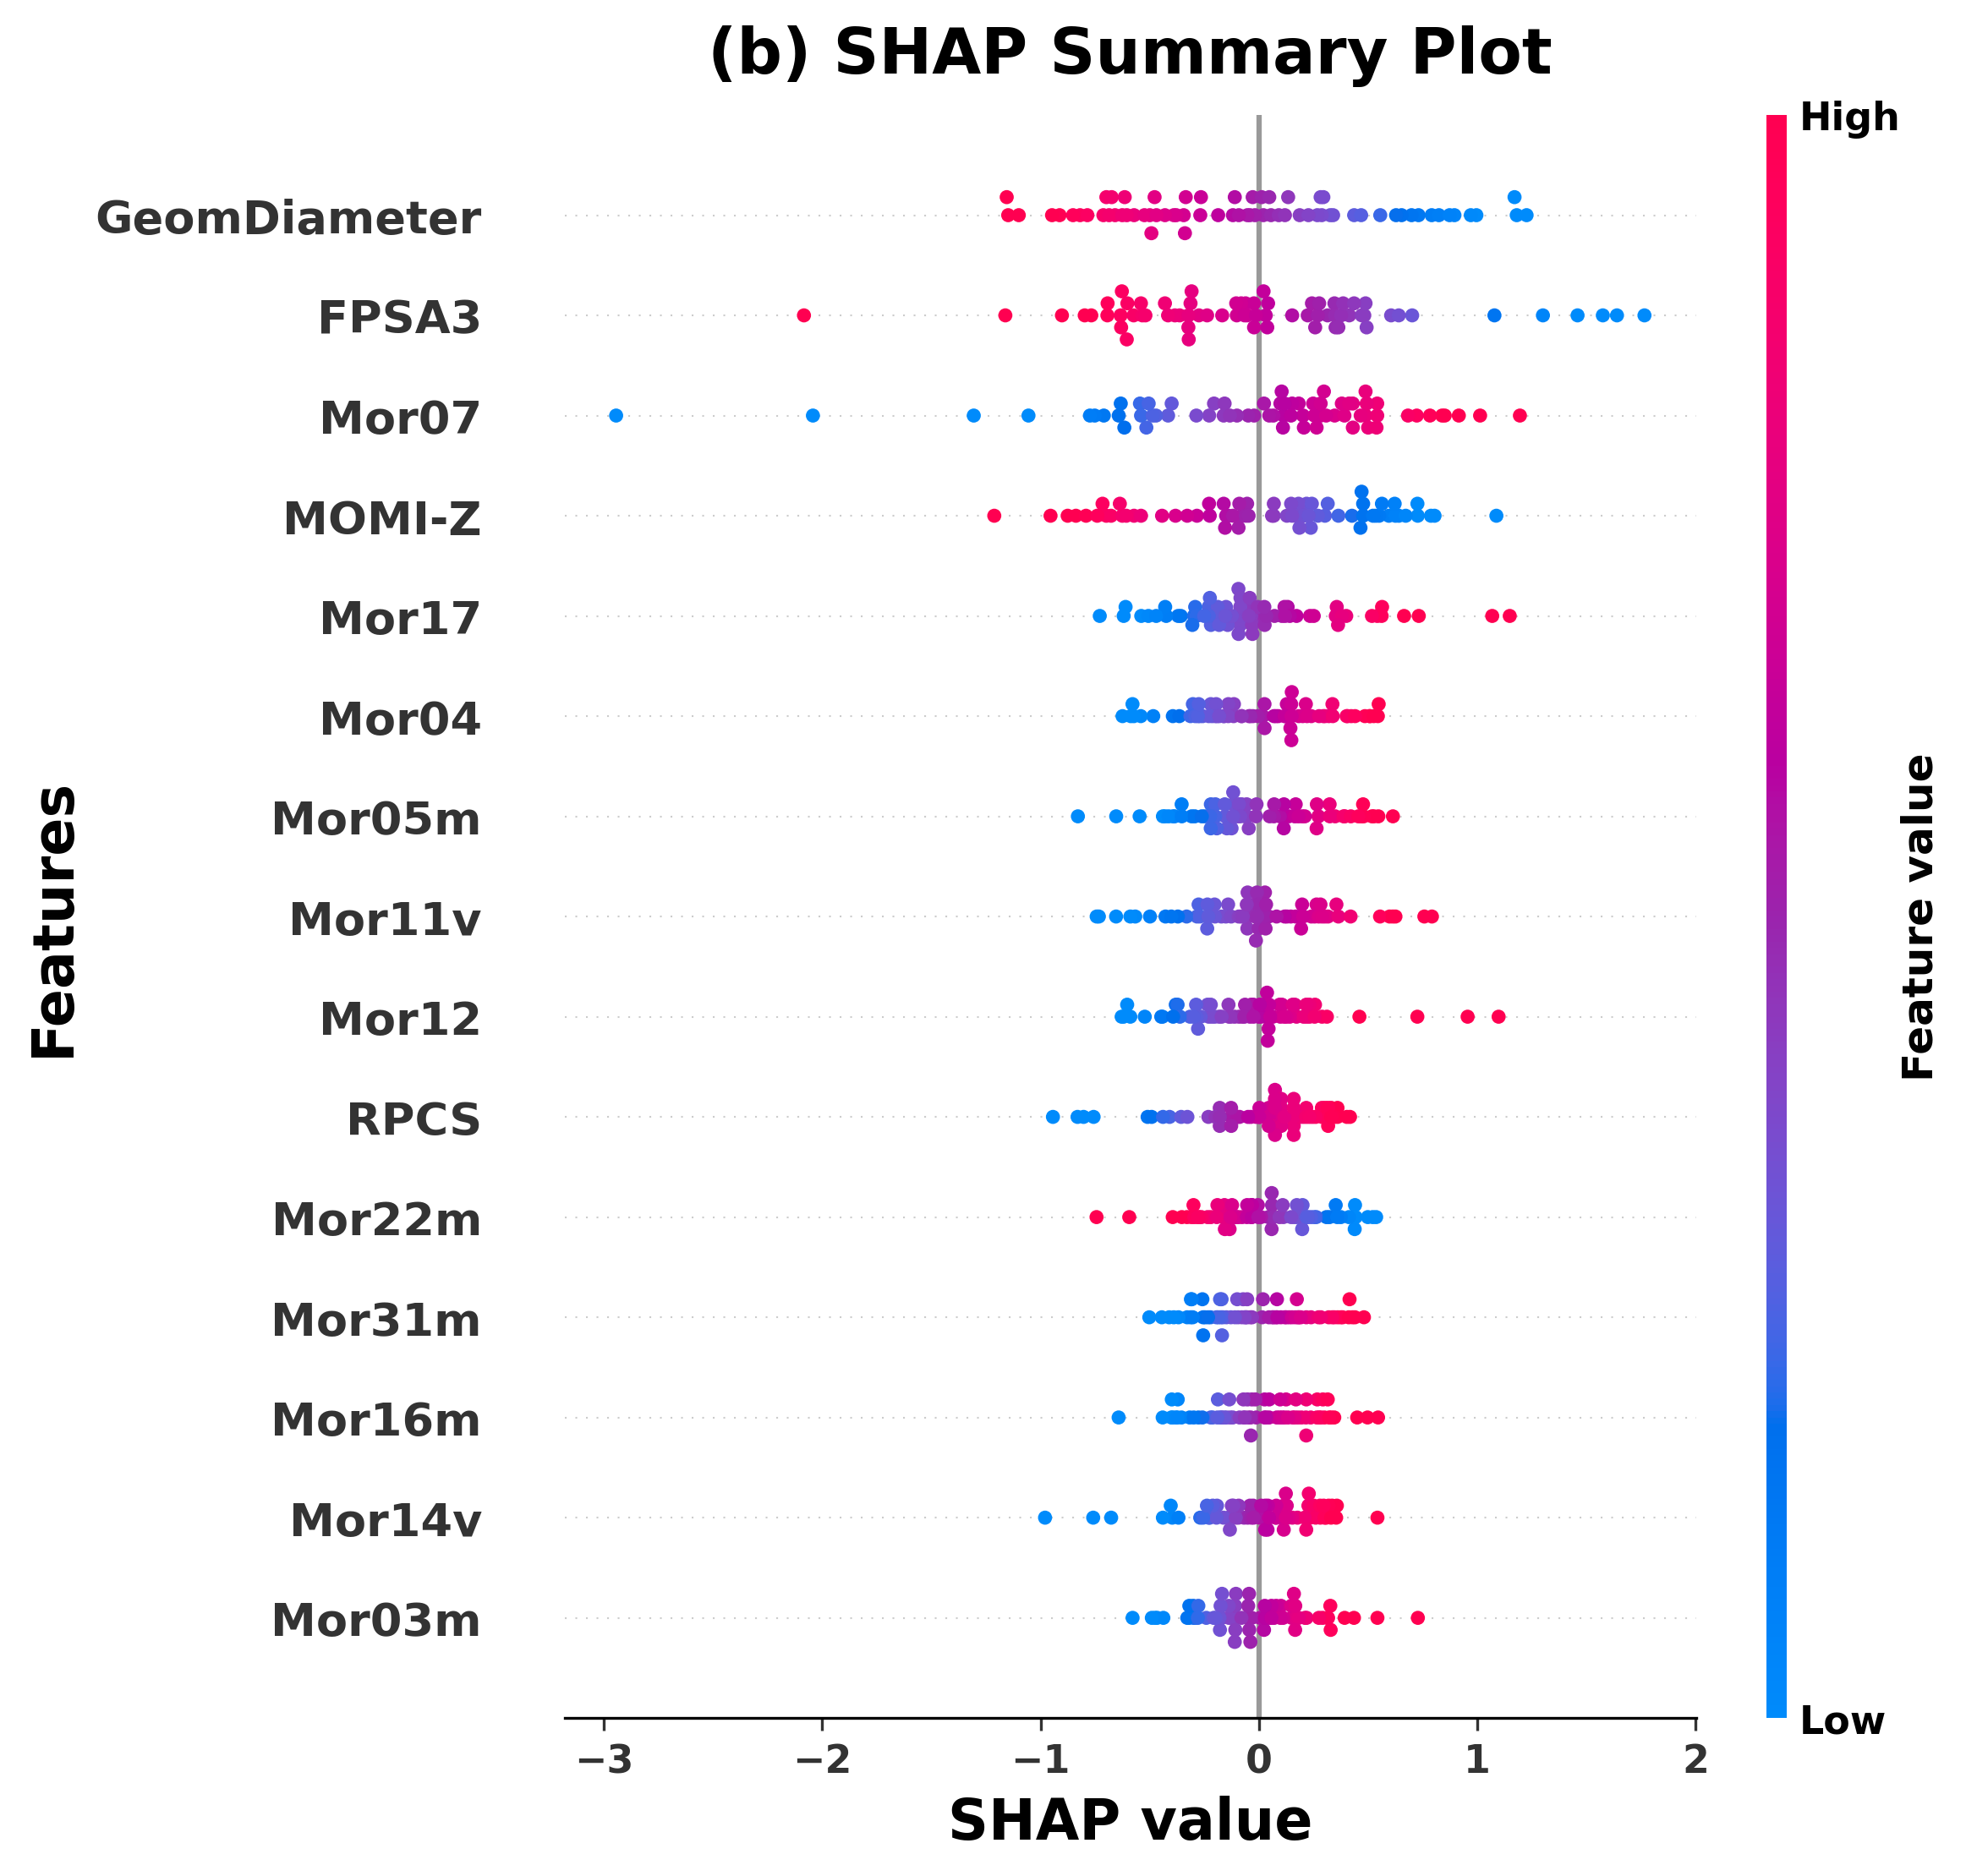

In [19]:
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'

svm_model = pipeline.named_steps["model"]
explainer = shap.LinearExplainer(svm_model, X_train_scaled)

# SHAP values
shap_values = explainer.shap_values(X_test_scaled)

plt.figure(figsize=(7,5), dpi=300)

shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_train.columns,
    # cmap="coolwarm",
    max_display=15,
    show=False
)

ax = plt.gca()
ax.set_title("(b) SHAP Summary Plot", fontsize=18, fontweight="bold", pad=12)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

fig = plt.gcf()
for ax in fig.axes:
    if ax.get_ylabel() == "Feature value":
        ax.yaxis.label.set_weight("bold")
        for label in ax.get_yticklabels():
            label.set_fontweight("bold")

plt.xlabel("SHAP value", fontsize=16, fontweight="bold")
plt.ylabel("Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()